# Project Brief 

In this project, I want to predict the total number of bike rentals in one hour (cnt).
The dataset contains hourly data from 2011 to 2012.
Each row represents one hour.

The data includes information like hour of the day, season, weekday, temperature, humidity, windspeed, and weather condition.

My goal is to build a regression model that can estimate how many bikes will be rented in a given hour using this information.

This problem is useful because it can help manage bike availability and avoid shortages or too many unused bikes.

I will first build simple baseline models, then try more advanced models.

I will measure performance using MAE and RMSE.

A good result means my model performs better than the baseline and works well on future data.

## 5 Features I Expect to Matter

1. hr (hour of the day)
I expect this to matter because people rent bikes more during rush hours like morning and evening.

2. temp (temperature)
When the weather is warm, more people are likely to rent bikes. Very cold weather may reduce rentals.

3. weathersit (weather condition)
Bad weather like rain or snow will probably reduce the number of bike rentals.

4. workingday
On working days, people may use bikes to go to work, so rentals might be higher than weekends.

5. season
Different seasons may affect bike usage. For example, winter might have fewer rentals than summer.

## Questions
#### 1. What is a prediction error that would be acceptable in the real world here?

An acceptable error would be small enough that the bike stations can still manage supply correctly. For example, being wrong by 10–20 bikes per hour might be acceptable, but being wrong by 100 bikes would cause problems. The acceptable error also depends on how many bikes are usually rented in that hour.

### 2. What would make your model unusable or misleading?

The model would be unusable if it makes very large errors during hours when many bikes are renteds. It would also be misleading if it performs well on training data but fails on future/unseen data.

# Load data and column understanding

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [8]:
df = pd.read_csv('hour.csv')
df.head(3)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


In [9]:
df.shape

(17379, 17)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [4]:
df.dtypes

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [5]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [6]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### Questions 
• Which columns are categorical vs numeric?

• Which columns are IDs or dates? Which should (or should not) be used directly?

| Column     | Meaning                                       | Type        | Use as Predictor? |
| ---------- | --------------------------------------------- | ----------- | ----------------- |
| instant    | Row ID                                        | ID          | No                |
| dteday     | Date of record                                | date        | No                |
| season     | Season (1=Spring, 2=Summer, 3=Fall, 4=Winter) | categorical | Yes               |
| yr         | Year (0=2011, 1=2012)                         | categorical | Yes               |
| mnth       | Month (1–12)                                  | categorical | Yes               |
| hr         | Hour of day (0–23)                            | categorical | Yes               |
| holiday    | Whether it is a holiday (0/1)                 | categorical | Yes               |
| weekday    | Day of week (0=Sunday … 6=Saturday)           | categorical | Yes               |
| workingday | Whether it is a working day (0/1)             | categorical | Yes               |
| weathersit | Weather situation (1–4)                       | categorical | Yes               |
| temp       | Normalized temperature                        | numeric     | Yes               |
| atemp      | Normalized “feels like” temperature           | numeric     | Yes               |
| hum        | Humidity                                      | numeric     | Yes               |
| windspeed  | Windspeed                                     | numeric     | Yes               |
| casual     | Casual rentals                                | numeric     | No                |
| registered | Registered rentals                            | numeric     | No                |
| cnt        | Total rentals (target)                        | numeric     | Target            |




In [7]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

In [21]:
df["holiday"].value_counts()


holiday
0    16879
1      500
Name: count, dtype: int64

In [27]:
df["hum"].value_counts()

hum
0.88    657
0.83    630
0.94    560
0.87    488
0.70    430
       ... 
0.08      1
0.12      1
0.13      1
0.97      1
0.91      1
Name: count, Length: 89, dtype: int64

# Exploratory Data Analysis(EDA) 


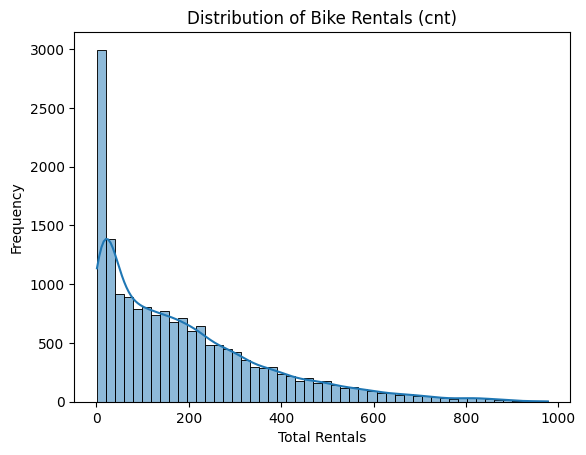

In [48]:
# Hypothesis:

# I expect cnt to be right-skewed — most hours have moderate rentals, few hours have very high rentals.

sns.histplot(df['cnt'], bins=50, kde=True)
plt.title('Distribution of Bike Rentals (cnt)')
plt.xlabel('Total Rentals')
plt.ylabel('Frequency')
plt.show()


In [43]:
df["cnt"].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64